# Check the SED Output for DiskMINT

In [1]:
# %matplotlib widget
%matplotlib inline

import datetime, os, sys, copy

import numpy as np
import pandas as pd

from astropy.io import fits
import astropy.units as u
import astropy.constants as C

import tqdm

# for interpolate
from scipy import interpolate
from scipy.optimize import curve_fit

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cmasher as cmr

style = [
    # 'seaborn-ticks',
    {
        'figure.dpi': 300,
        'figure.figsize': (3.5, 3.5 / 1.618),
        'font.size': 12,  # 12
        'image.cmap': 'inferno',
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman'] + plt.rcParams['font.serif'],
        'xtick.top': True,
        'xtick.direction': 'out',
        'ytick.right': True,
        'ytick.direction': 'out',
        'mathtext.fontset': 'cm'
        }]

plt.style.use(style)

import platform
if platform.node() == 'garnet':
    github_dir = '/home/dingshandeng/github/DiskModeling/' # garnet
elif platform.node() == 'graphite':
    github_dir = "/Users/dingshandeng/github/DiskModeling/" # macos
elif platform.node() == 'fld':
    github_dir = "/tank/data/research/software/DiskMINT/" # fld
    
package_position = os.path.join(github_dir)
sys.path.append(os.path.join(package_position, "src"))

import diskmint.model as model
import diskmint.disk_density as dd
import diskmint.constants as const
import diskmint.modelgrid as modelgrid
import diskmint.dustopac as dustopac
import diskmint.execute as exe

## Import the utils for this work

In [5]:
# navigate to the work direcotry

work_dir = "/tank/data/research/ice_in_disk/diskmint_models/diskmint_model_similar_to_HH30_example/"
working_dir = work_dir

os.chdir(work_dir)
print(os.getcwd())
sys.path.append(os.getcwd())

project_dir = os.path.join("/tank", "data", "research", "ice_in_disk")
sys.path.append(os.path.join(project_dir, '0-Utils'))
import diskmint_utils as utils

/tank/data/research/ice_in_disk/diskmint_models/diskmint_model_similar_to_HH30_example


## Select the Model

In [7]:
output_dir = os.path.join(work_dir, 'output')
# output_dir = '/ksdata/dingshandeng/diskmint_grids/output_0707/'
model_dirs = sorted([d for d in os.listdir(output_dir)
                     if os.path.isdir(os.path.join(output_dir, d))])

print(model_dirs)

['diskmint_similar_to_HH30_example_20260223_t0_mdust1p0e-04ms_gtd100_pla3p50_amax0p10']


In [8]:
# --- change here to select the model dir to read in ---

i_model_select = 0 # select the first model in the model_dirs
model_name_in_figure = "similar_to_HH30" # choose a name to show in the figure, can be different from the model_name which is used to read in the data

# --- end changing here ---

model_name = model_dirs[i_model_select]

output_for_this_model_dir = os.path.join(output_dir, model_name)

para = model.Parameters()
para.read_parameters_from_csv(directory=output_for_this_model_dir, filename=model_name+'_parameters', extension='.csv')

specific_g2d_ref_name = os.path.join(work_dir, 'ratio_g2d_reference.dat')
if os.path.exists(specific_g2d_ref_name):
    print('read the specific g2d ref file %s'%(specific_g2d_ref_name))
    ratio_g2d_reference = np.loadtxt(specific_g2d_ref_name)

mint = model.Mint(para, file_dir=output_for_this_model_dir)
mint.setup_dust_info(para, bool_savefile=False)

Used the powerlow for surface density and tapering-off: -1.000; 1.000
Used the Method 1 to setup Hp, with Hp100 = 10.000
the g2d ratio set up is a constant (float or float64 or integer), with ratio_g2d=100.00
input primary mdiskd: 1.000e-04 [ms]
setup primary mdiskd: 1.000e-04 [ms]
input secondary mdiskd_2: 0.000e+00 [ms]
setup secondary mdiskd_2: 0.000e+00 [ms]
setup total mdiskd: 1.000e-04 [ms]
setup mdiskg: 1.000e-02 [ms]
setup gtd: 1.000e+02
Computing Frations of Dust Species Assuming in the same Slope


1

## Parameters for star

In [9]:
Teff_star = 3802 * u.K
Rstar = 1.9 * u.R_sun
mstar = 0.5 * u.M_sun
g = (C.G * mstar/Rstar**2).to(u.cm/u.s**2)
# print(g)

# new distance and rstar values
# Stellar Paramters (Mainly for distance)
distance = 150.0 # pc
rstar_pc = (Rstar).to(u.pc).value  # old 1.64; 2.4 by me; 2.55 by Woitke

## Read the Observational SED and Convert to unufnu and plot

In [10]:
# TBA

## Read the Stellar Spectra

In [11]:
# read in the star spectrum
file_spec = "BTSettl_0p5Msolar_1pc_um_ergpcm2hzs.inp"
data_spec = np.loadtxt(os.path.join(output_for_this_model_dir, file_spec), skiprows=1)

## Plot

In [16]:
import radmc3dPy

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


similar to HH30


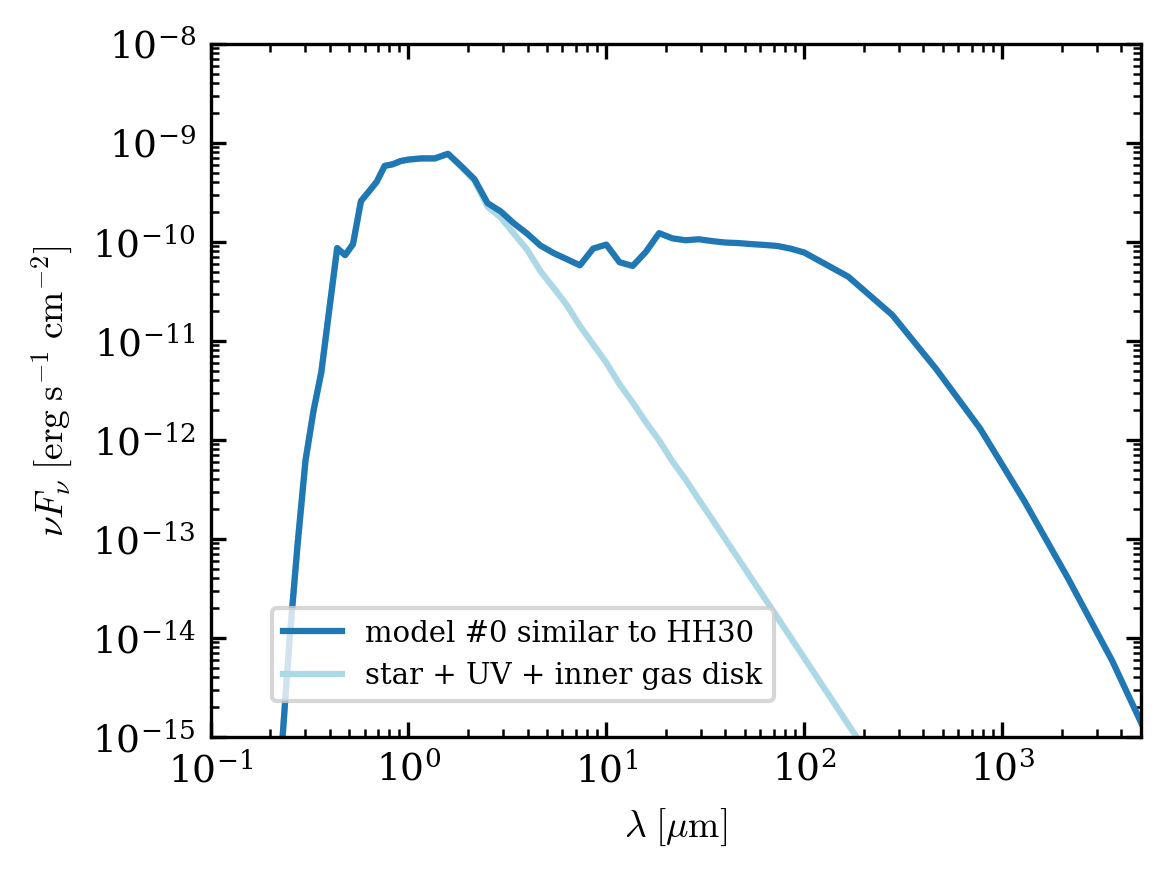

In [20]:
#
# GRID Define
#

fig0 = plt.figure(dpi=300, figsize = (4, 3))
ax_sed0 = fig0.add_subplot(1,1,1)

##########################
### Observational Data ###
##########################

# Photometry

# for ref_i in ref_list:
#     df_i = df[df['ref'] == ref_i]
#     nu_i = (df_i['wave'].values * u.um).to(u.Hz, equivalencies=u.spectral()).value

#     if ref_i == 'Lommen07':
#         ref_i = 'Lommen09'
#     elif ref_i == 'Lommen08':
#         ref_i = 'Lommen07'

#     # the 1e23 is the factor for convert the unit from HzJy to erg/cm2/s
#     plt.errorbar(df_i['wave'], nu_i * df_i['flux']/1e23, yerr = nu_i * df_i['sigma_tot']/1e23, label = ref_i,\
#                 fmt = 'o', elinewidth = 2, capsize = 10)

# plt.errorbar(wave_obs, nufnu_obs, yerr = nu_obs*err_fluxes_obs, label = 'observations',\
#                 fmt = 'o', elinewidth = 2, capsize = 10, zorder = 0)

# # Photometry + UV photometry
# xdatah = df_obswuv['wave'].values 
# ydatah = df_obswuv['nufnu'].values/1e23
# yerrh  = df_obswuv['err_nufnu'].values/1e23

# for ax_sed in [ax_sed0]:

#     # plot obs together
#     # ax_sed.fill_between(xdatah, ydatah - yerrh, ydatah + yerrh, color = 'grey', zorder = -1)
#     color_obs = 'dimgrey'
#     # ax_sed.scatter(xdatah, ydatah, label = 'observation', c = color_obs, s=1, alpha=0.5, zorder = 10)
#     ax_sed.errorbar(xdatah, ydatah, yerrh, ecolor = color_obs, color=color_obs, fmt='o', capsize=1.5, markersize=2, alpha=0.6, label = 'observation', zorder = 11)

##################
### Model Data ###
##################

wave_mod_wuv = data_spec[:, 0]
fluxes_mod_wuv = data_spec[:, 1]
nu_mod_wuv = (wave_mod_wuv * u.um).to(u.Hz, equivalencies=u.spectral()).value
nufnu_mod_wuv = nu_mod_wuv * fluxes_mod_wuv

for ax_sed in [ax_sed0]:
    ax_sed.plot(wave_mod_wuv, nufnu_mod_wuv*(1/distance)**2, color='lightblue', label='star + UV + inner gas disk')

    # ax_sed.plot(wave_r22spec.to(u.um), nufnu_r22spec, color='red', label='new stellar spectra')

#######################
### RADMC-3D Result ###
#######################

model_name_list = [
    model_dirs[i_model_select],
]

sed_data_dir_list = [
    os.path.join(output_dir, model_dirs[i_model_select])
]

color_list = ['C0', 'C2', 'C3', 'C4', 'C5', 'C6'] 

note_list = [
    'similar to HH30',
    ] * len(sed_data_dir_list)

for ii, sed_data_dir in enumerate(sed_data_dir_list):

    specname = os.path.join(sed_data_dir, "spectrum.out")

    s     = radmc3dPy.analyze.readSpectrum(specname)
    lam   = s[:,0]
    nu    = 1e4*radmc3dPy.natconst.cc/lam
    fnu   = s[:,1]
    #             nufnu_1pc = nu*fnu # the model seen from 1pc
    #             # scale according to its distance
    fnu_here = (fnu * (1/distance)**2)

    factor_mdiskd = 1.00 # 0.90
    
    print(note_list[ii])
    
    for ax_sed in [ax_sed0]:
    
        ax_sed.plot(lam, nu * fnu_here * factor_mdiskd, label = 'model #%i '%(ii)+'%s'%(note_list[ii]), color=color_list[ii], linestyle='-')
        
################################
### control factors for plot ###
################################

for ax_sed in [ax_sed0]:
    
    ax_sed.set_xscale('log')
    ax_sed.set_yscale('log')

"""whole region"""
ax_sed = ax_sed0
ax_sed.set_xlim(1e-1, 5e3)
ax_sed.set_ylim(1e8/1e23,1e15/1e23)

"""IR to mm"""
# ax_sed = ax_sed0
# ax_sed.set_xlim(1, 5e3)
# ax_sed.set_ylim(1e-13, 1e-9)

"""DSHARP wavelengths"""
# ax_sed = ax_sed0
# ax_sed.set_xlim(500, 4e3)
# ax_sed.set_ylim(1e-13, 5e-12)

"""mm and beyond"""
# ax_sed.set_xlim(500, 1e4)
# ax_sed.set_ylim(1e-15, 5e-12)

for ax_sed in [ax_sed0]:

    ax_sed.set_xlabel('$\lambda\; [\mu \mathrm{m}]$')
    ax_sed.set_ylabel('$\\nu F_\\nu \; [\mathrm{erg} \; \mathrm{s^{-1}} \; \mathrm{cm^{-2}}]$')

    handles, labels = ax_sed.get_legend_handles_labels()
    reorder = [int(len(handles)-1)] + [int(i) for i in range(len(handles)-1)]
    handles = [handles[i] for i in reorder]
    labels = [labels[i] for i in reorder]
    ax_sed.legend(handles, labels, loc = 'lower left', fontsize = 7, bbox_to_anchor=(0.05, 0.03))

# plt.savefig('./figures/Fig_SED_fitting.png', dpi = 300, bbox_inches='tight', pad_inches=0.1)

plt.show()